### Importing Libraries

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv("tech_job_market_2019_2026.csv")
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1


In [33]:

df.shape
df.info()
     

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  object 
 1   company_name                  115000 non-null  object 
 2   company_type                  115000 non-null  object 
 3   sector                        115000 non-null  object 
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  object 
 6   job_role                      115000 non-null  object 
 7   seniority_level               115000 non-null  object 
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  object 
 11  primary_programming_language  92525 non-null   object 
 12  work_mode                     115000 non-nul

In [34]:
df.isnull().sum()

job_id                              0
company_name                        0
company_type                        0
sector                              0
company_size_employees              0
hq_country                          0
job_role                            0
seniority_level                     0
years_experience_min                0
years_experience_max                0
required_tech_stack                 0
primary_programming_language    22475
work_mode                           0
visa_sponsorship_offered            0
job_location_country                0
job_location_city               25107
salary_currency                     0
posting_date                        0
application_deadline             5757
date_position_filled            25781
position_status                     0
number_of_applicants             1110
number_of_interview_rounds        436
offers_extended                   330
offers_accepted                   330
salary_min_usd                   3318
salary_max_u

**Conclusion**
- posting_date, application_deadline, date_position_filled should be dates but are stroed as string
- salary_min_usd and salary_max_usd should be numbers but are stored as string.

In [35]:
for col in ['primary_programming_language', 'salary_min_usd', 'salary_max_usd']:
    print(col, ':', df[col].isin(['Unknown', 'TBD', 'Not Disclosed']).sum())
     

primary_programming_language : 1093
salary_min_usd : 686
salary_max_usd : 686


In [36]:

print('duplicate rows:', df.duplicated().sum())
print('duplicate job_id:', df['job_id'].duplicated().sum())
df.drop_duplicates(inplace=True)

duplicate rows: 1193
duplicate job_id: 2000


- there are duplicate job_ids in the data

### Fixing categories (Removing duplicate values)

In [37]:
df['sector'].value_counts()

sector
E-commerce       16491
HealthTech       15125
Fintech          13008
EdTech           11414
Social/AdTech     8938
AI/ML             8803
SaaS              8522
Crypto/Web3       7954
Cloud/Infra       6502
Cybersecurity     5677
Logistics         5231
Gaming            4985
e-commerce         172
healthtech         145
fintech            139
edtech             125
social/adtech       99
saas                88
crypto/web3         87
ai/ml               87
cloud/infra         60
gaming              57
logistics           49
cybersecurity       49
Name: count, dtype: int64

In [38]:
df['sector'] = df['sector'].str.strip().str.lower()
df['sector'] = df['sector'].str.replace('e-commerce','E-commerce')
df['sector'] = df['sector'].str.replace('healthtech','HealthTech')
df['sector'] = df['sector'].str.replace('fintech','Fintech')
df['sector'] = df['sector'].str.replace('edtech','EdTech')
df['sector'] = df['sector'].str.replace('social/adtech','Social/AdTech')
df['sector'] = df['sector'].str.replace('ai/ml','AI/ML')
df['sector'] = df['sector'].str.replace('saas','SaaS')
df['sector'] = df['sector'].str.replace('crypto/web3','Crypto/Web3')
df['sector'] = df['sector'].str.replace('cybersecurity','Cybersecurity')
df['sector'] = df['sector'].str.replace('logistics','Logistics')
df['sector'] = df['sector'].str.replace('gaming','Gaming')
df['sector'].value_counts()

sector
E-commerce       16663
HealthTech       15270
Fintech          13147
EdTech           11539
Social/AdTech     9037
AI/ML             8890
SaaS              8610
Crypto/Web3       8041
cloud/infra       6562
Cybersecurity     5726
Logistics         5280
Gaming            5042
Name: count, dtype: int64

In [39]:
df['work_mode'].value_counts()

work_mode
Hybrid            48423
Remote            31986
Onsite            26470
HYBRID             1487
hybrid             1333
remote              593
Work From Home      560
WFH                 556
REMOTE              548
ONSITE              472
onsite              463
In-office           461
On-site             455
Name: count, dtype: int64

In [40]:

df['work_mode'] = df['work_mode'].str.strip().str.lower()
df['work_mode'] = df['work_mode'].str.replace('work from home', 'remote')
df['work_mode'] = df['work_mode'].str.replace('wfh', 'remote')
df['work_mode'] = df['work_mode'].str.replace('on-site', 'onsite')
df['work_mode'] = df['work_mode'].str.replace('in-office', 'onsite')
df['work_mode'].value_counts()

work_mode
hybrid    51243
remote    34243
onsite    28321
Name: count, dtype: int64

In [41]:
df['visa_sponsorship_offered'].value_counts()

visa_sponsorship_offered
0        19625
False    19555
N        19553
No       19346
Yes       9001
True      8937
1         8897
Y         8893
Name: count, dtype: int64

In [43]:
df['visa_sponsorship_offered'] = df['visa_sponsorship_offered'].replace(
    {"False": 0, "No": 0, "N": 0, "True": 1, "Yes": 1, "Y": 1, "0": 0, "1": 1})
df['layoff_within_12_months_flag'] = df['layoff_within_12_months_flag'].replace(
    {"False": 0, "No": 0, "N": 0, "True": 1, "Yes": 1, "Y": 1, "0": 0, "1": 1})

C:\Users\anshu\AppData\Local\Temp\ipykernel_33648\3942126322.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['visa_sponsorship_offered'] = df['visa_sponsorship_offered'].replace(
C:\Users\anshu\AppData\Local\Temp\ipykernel_33648\3942126322.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['layoff_within_12_months_flag'] = df['layoff_within_12_months_flag'].replace(


In [44]:
df['visa_sponsorship_offered'].value_counts()

visa_sponsorship_offered
0    78079
1    35728
Name: count, dtype: int64

### Cleaning salary

In [45]:

df['salary_min_usd'] = df['salary_min_usd'].astype(str)
df['salary_min_usd'] = df['salary_min_usd'].str.replace('$', '', regex=False)
df['salary_min_usd'] = df['salary_min_usd'].str.replace('USD', '', regex=False)
df['salary_min_usd'] = df['salary_min_usd'].str.replace(',', '', regex=False)
df['salary_min_usd'] = df['salary_min_usd'].replace('Not Disclosed', np.nan)
df['salary_min_usd'] = pd.to_numeric(df['salary_min_usd'], errors='coerce')
df.loc[df['salary_min_usd'] < 0, 'salary_min_usd'] = np.nan

df['salary_max_usd'] = df['salary_max_usd'].astype(str)
df['salary_max_usd'] = df['salary_max_usd'].str.replace('$', '', regex=False)
df['salary_max_usd'] = df['salary_max_usd'].str.replace('USD', '', regex=False)
df['salary_max_usd'] = df['salary_max_usd'].str.replace(',', '', regex=False)
df['salary_max_usd'] = df['salary_max_usd'].replace('Not Disclosed', np.nan)
df['salary_max_usd'] = pd.to_numeric(df['salary_max_usd'], errors='coerce')
df.loc[df['salary_max_usd'] < 0, 'salary_max_usd'] = np.nan

df['salary_min_usd'].describe()

count    109118.000000
mean     115425.432101
std       57020.394161
min        1700.000000
25%       76500.000000
50%      105900.000000
75%      146100.000000
max      531800.000000
Name: salary_min_usd, dtype: float64

In [ ]:
df['salary_min_usd'].value_counts()

salary_min_usd
95600.0     120
77000.0     117
102000.0    116
96700.0     116
94800.0     115
           ... 
279200.0      1
361700.0      1
327200.0      1
306800.0      1
436500.0      1
Name: count, Length: 3623, dtype: int64

### Univariant analysis

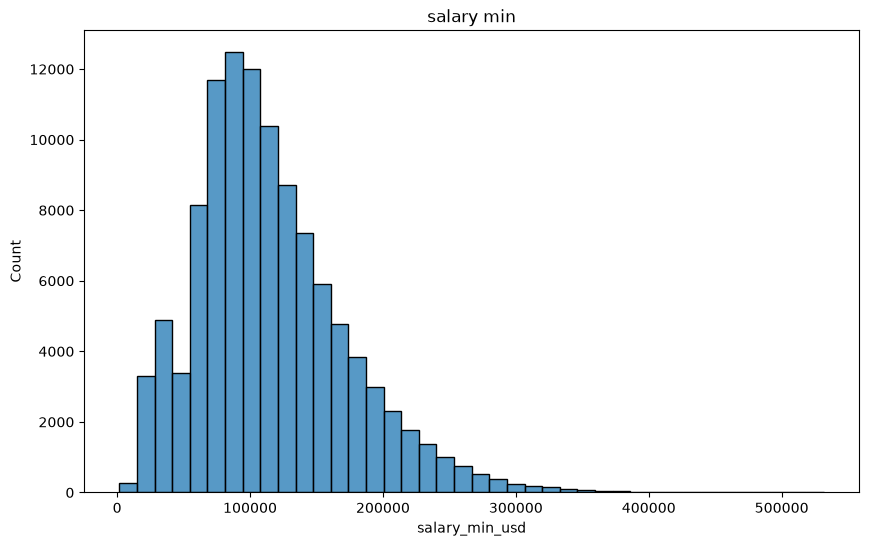

In [50]:
plt.figure(figsize=(10,6))
sns.histplot(df['salary_min_usd'].dropna(), bins=40)
plt.title('salary min')
plt.show()
     

In [54]:
df['salary_min_usd'].skew()

np.float64(0.9628020279183048)

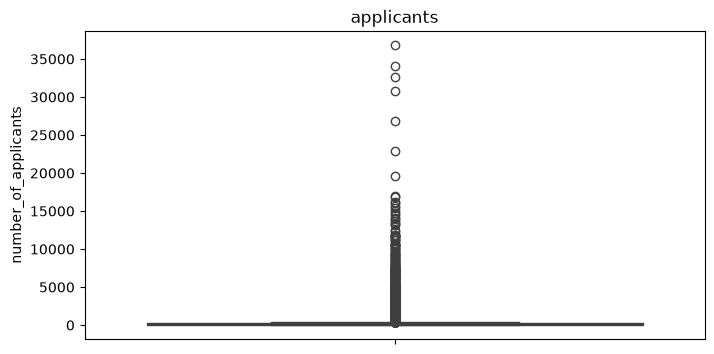

In [53]:
plt.figure(figsize=(8,4))
sns.boxplot(y=df['number_of_applicants'])
plt.title('applicants')
plt.show()

- Outliers are very high in this column

### Bivariant analysis

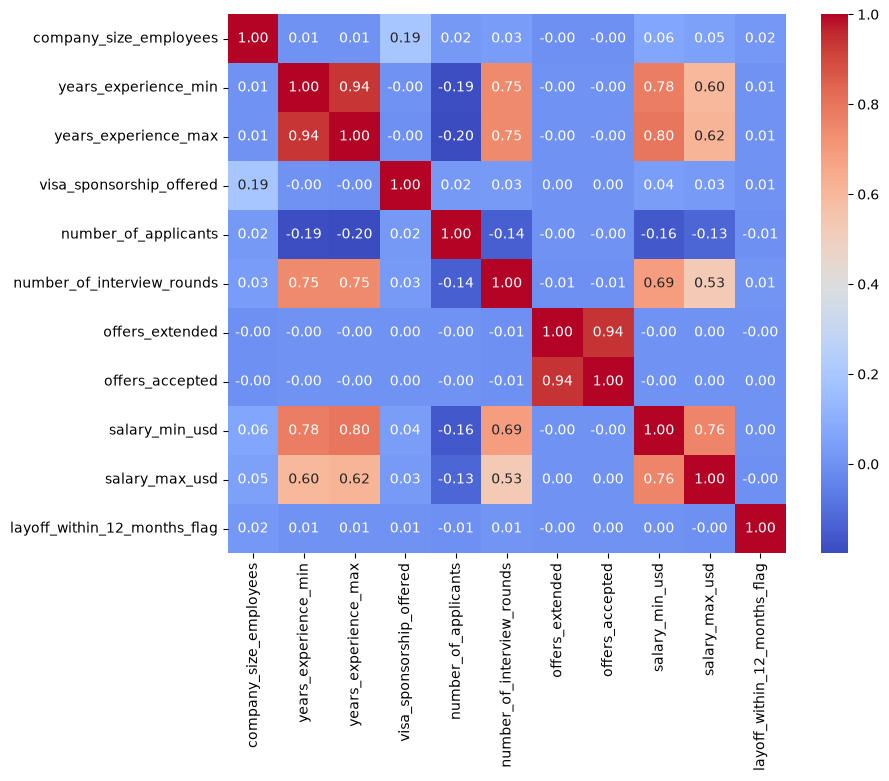

In [59]:

plt.figure(figsize=(9,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()
     

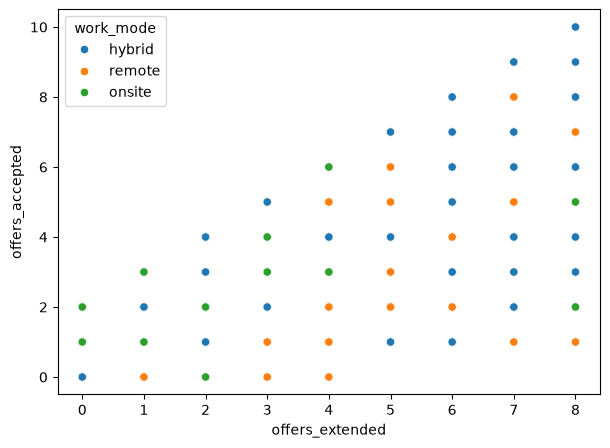

In [60]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='offers_extended', y='offers_accepted', data=df, hue='work_mode')
plt.show()

- offers_accepted exceeds offers_extended in some rows, not possible

In [62]:

(df['offers_accepted'] > df['offers_extended']).sum()
     


     

np.int64(544)

In [63]:
df.loc[df['offers_extended'] == 0, 'offers_accepted'] = 0
(df['offers_accepted'] > df['offers_extended']).sum()

np.int64(544)

- fixed the rows where offers_extended was 0, rest left as is since we don't know the true vacancy count

In [64]:
mask = df['years_experience_min'] > df['years_experience_max']
mask.sum()

np.int64(315)

In [65]:
df.loc[mask,['years_experience_min','years_experience_max']] = df.loc[mask,['years_experience_max','years_experience_min']].values

- 315 rows had min > max experience, likely swapped during entry, so swapped them back

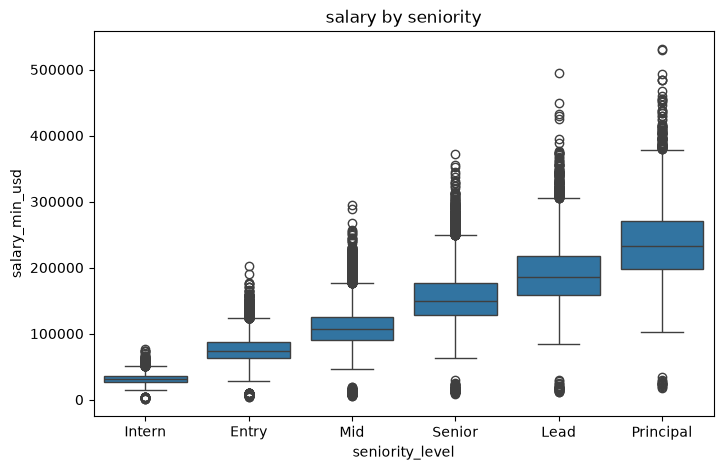

In [66]:
plt.figure(figsize=(8,5))
sns.boxplot(x='seniority_level', y='salary_min_usd', data=df,
            order=['Intern', 'Entry', 'Mid', 'Senior', 'Lead', 'Principal'])
plt.title('salary by seniority')
plt.show()


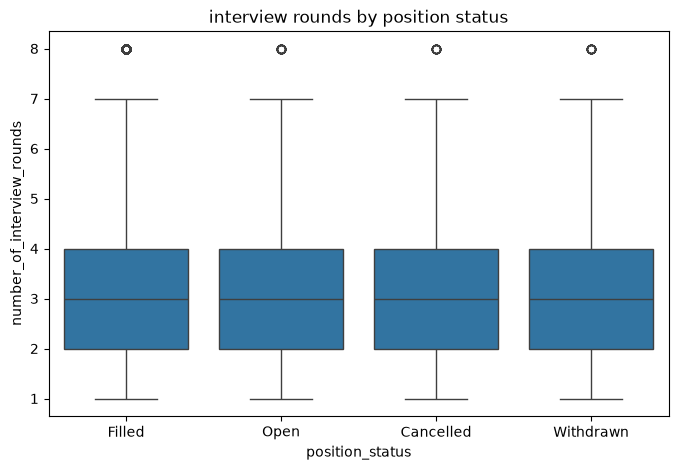

In [67]:

plt.figure(figsize=(8,5))
sns.boxplot(x='position_status', y='number_of_interview_rounds', data=df)
plt.title('interview rounds by position status')
plt.show()
     

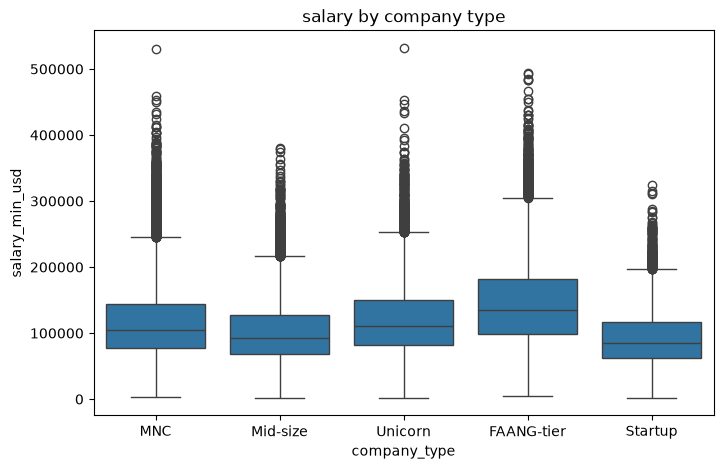

In [68]:
plt.figure(figsize=(8,5))
sns.boxplot(x='company_type', y='salary_min_usd', data=df)
plt.title('salary by company type')
plt.show()

### Time based analysis

In [69]:
df['posting_date'] = pd.to_datetime(df['posting_date'], errors='coerce')
df['date_position_filled'] = pd.to_datetime(df['date_position_filled'], errors='coerce')
df['year'] = df['posting_date'].dt.year

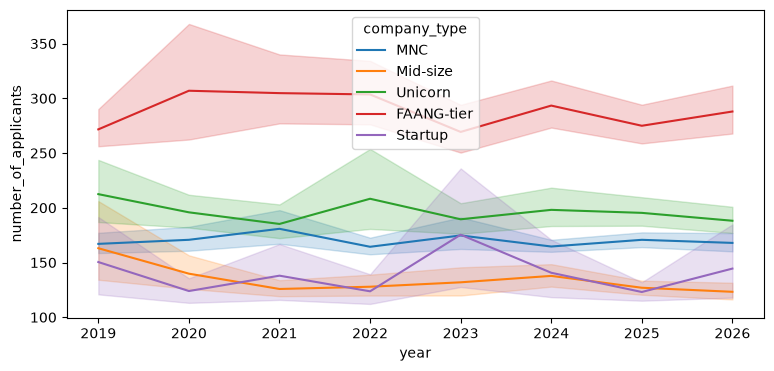

In [70]:
plt.figure(figsize=(9,4))
sns.lineplot(x='year', y='number_of_applicants', hue='company_type', data=df)
plt.show()

### Feature engineering

In [71]:
df['offer_accept_ratio'] = df['offers_accepted'] / df['offers_extended']
     

In [72]:
df['time_to_fill_days'] = (df['date_position_filled'] - df['posting_date']).dt.days
df.loc[df['time_to_fill_days'] < 0, 'time_to_fill_days'] = np.nan
df['time_to_fill_days'].describe()
     

count    87854.000000
mean        46.607064
std         22.960743
min          4.000000
25%         30.000000
50%         43.000000
75%         59.000000
max        240.000000
Name: time_to_fill_days, dtype: float64

In [73]:
df['avg_salary_usd'] = (df['salary_min_usd'] + df['salary_max_usd']) / 2

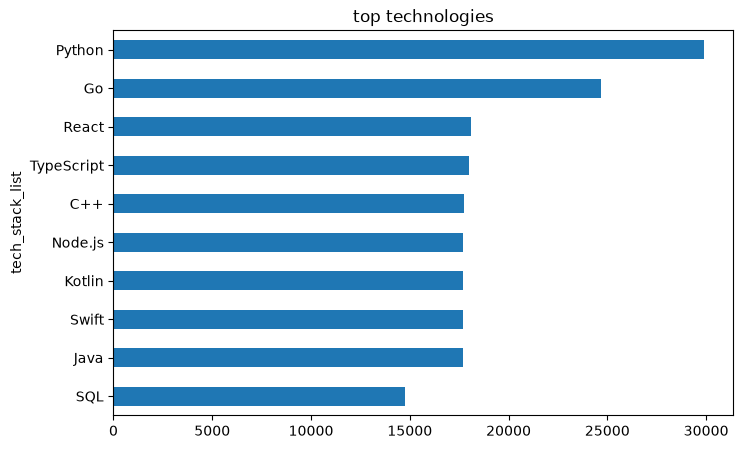

In [74]:
df['tech_stack_list'] = df['required_tech_stack'].str.split(', ')
df['tech_stack_count'] = df['tech_stack_list'].apply(len)
top_tech = df['tech_stack_list'].explode().value_counts().head(10)

plt.figure(figsize=(8,5))
top_tech.plot(kind='barh')
plt.title('top technologies')
plt.gca().invert_yaxis()
plt.show()

**Conclusion**

- salary and date columns needed cleaning before use
- work_mode, sector, visa, layoff columns had inconsistent spellings, fixed
- experience swap and offers_accepted=0 fixed where the reason was clear, other issues (negative applicants, remaining offer mismatch, duplicate job_id) left as is and documented
- salary increases with seniority level
- most extended offers get accepted
- new columns: offer_accept_ratio, time_to_fill_days, avg_salary_usd, tech_stack_count